<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/08.11%2021_%EC%A0%84%EC%9D%B4%ED%95%99%EC%8A%B5_%EA%B0%80%EC%A3%BD%ED%92%88%EC%A7%88%EA%B2%80%EC%82%AC_VGG16_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 가죽 제품 비주얼 품질 검사 — TensorFlow/Keras 버전 (학생용 실습본)

**학습 목표**
- VGG16 전이학습으로 가죽 결함을 정상 / 불량으로 분류
- train + test 전체 데이터를 합쳐 80/20 분할 (원소스 PyTorch와 동일한 방식)

**구현 단계**
```
0단계. 데이터셋 소개
1단계. 라이브러리 임포트 및 기본 설정
2단계. 데이터 다운로드 및 확인
3단계. 데이터 준비 (get_dataset 함수)
4단계. 데이터 샘플 확인
5단계. 모델 구성 (VGG16 전이학습)
6단계. 모델 컴파일 & 학습
7단계. 학습 과정 시각화
8단계. 모델 평가 (혼동행렬)
9단계. 예측 결과 시각화
10단계. 모델 저장
```

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

## 0단계. 데이터셋 소개

**MVTec 이상 탐지 데이터셋 (가죽 부분만 사용)**

출처: https://www.mvtec.com/company/research/datasets/mvtec-ad (CC BY-NC-SA 4.0)

**폴더 구조**
```
data/leather/
├── train/
│   └── good/     ← 정상 이미지 (245장)
└── test/
    ├── good/     ← 정상 이미지 (32장)
    ├── color/    ← 색상 결함 (19장)
    ├── cut/      ← 절단 결함 (19장)
    ├── fold/     ← 접힘 결함 (17장)
    ├── glue/     ← 접착 결함 (19장)
    └── poke/     ← 구멍 결함 (18장)
```

**데이터 처리 방식 (원소스 PyTorch와 동일)**
```
train/good + test/good + test/결함폴더 전체를 하나로 합침
                ↓
    good → 정상(0), 나머지 → 불량(1) 레이블 부여
                ↓
        80% 훈련 / 20% 테스트 분할
```

## 1단계. 라이브러리 임포트 및 기본 설정

In [1]:
!pip install koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 44.0 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

print(f"TensorFlow 버전: {tf.__version__}")
print(f"GPU 사용 가능: {tf.config.list_physical_devices('GPU')}")

TensorFlow 버전: 2.20.0
GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 경로 및 기본 설정

In [5]:
DATA_DIR  = "./data/leather"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16
EPOCHS       = 20
LR           = 0.0001 # 학습률과 미리 비교기 만들어 두기

# 불량(1) 샘플이 정상(0) 대비 적으므로 3배 가중치 부여 (원소스와 동일)
CLASS_WEIGHT = {0: 1, 1: 3} # 결함이 너무 적으니깐 3배 가중치를 부여해야 한다

print(f"이미지 크기: {IMG_SIZE}, 배치: {BATCH_SIZE}, 에폭: {EPOCHS}, LR: {LR}")
print(f"클래스 가중치: {CLASS_WEIGHT}  → 불량에 3배 가중치")

이미지 크기: (224, 224), 배치: 16, 에폭: 20, LR: 0.0001
클래스 가중치: {0: 1, 1: 3}  → 불량에 3배 가중치


## 2단계. 데이터 다운로드 및 확인

In [4]:
# 데이터 다운로드 (Google Colab)
!gdown 1-kgB54Hhj8YX4xuq8e4faerBVA3XCNbd

Downloading...
From (original): https://drive.google.com/uc?id=1-kgB54Hhj8YX4xuq8e4faerBVA3XCNbd
From (redirected): https://drive.google.com/uc?id=1-kgB54Hhj8YX4xuq8e4faerBVA3XCNbd&confirm=t&uuid=54f68bb9-a60d-4232-9f6b-cf5fab766f37
To: /content/leather.tar.xz
100% 525M/525M [00:10<00:00, 48.6MB/s]


In [6]:

## .zip --> zipzipfile  .xz 처럼 tar 아카이브 압축 파일은 subprocess 의 tar을 사용하면 된다

import subprocess
os.makedirs("./data", exist_ok=True)
result = subprocess.run(["tar", "-xf", "leather.tar.xz", "-C", "./data/"])
print("압축 해제 완료" if result.returncode == 0 else "오류 발생")

압축 해제 완료


In [7]:
# 데이터 수량 확인
print("=== 원본 데이터 수량 ===")

good_train = len([f for f in os.listdir(os.path.join(TRAIN_DIR, "good")) if f.endswith(".png")])
good_test  = len([f for f in os.listdir(os.path.join(TEST_DIR,  "good")) if f.endswith(".png")])
print(f"train/good: {good_train}장")
print(f"test/good:  {good_test}장")

defect_total = 0
for folder in sorted(os.listdir(TEST_DIR)):
    if folder == "good": continue
    fp = os.path.join(TEST_DIR, folder)
    if os.path.isdir(fp):
        n = len([f for f in os.listdir(fp) if f.endswith(".png")])
        print(f"test/{folder}: {n}장  (불량)")
        defect_total += n

print(f"\n정상 합계: {good_train + good_test}장")
print(f"불량 합계: {defect_total}장")
print(f"전체 합계: {good_train + good_test + defect_total}장")

=== 원본 데이터 수량 ===
train/good: 245장
test/good:  32장
test/color: 19장  (불량)
test/cut: 19장  (불량)
test/fold: 17장  (불량)
test/glue: 19장  (불량)
test/poke: 18장  (불량)

정상 합계: 277장
불량 합계: 92장
전체 합계: 369장


## 3단계. 데이터 준비

```
train/good + test/good  →  레이블 0 (정상)
test/color, cut, fold, glue, poke  →  레이블 1 (불량)
                    ↓
           전체를 80/20 으로 분할
           → train_dataset (80%)
           → test_dataset  (20%)
```

이 방식의 장점: 별도 데이터 재구성 없이 원본 폴더 구조 그대로 사용

In [9]:
def get_dataset(data_dir, img_size, batch_size, test_size=0.2, random_state=42):
    """
    train/ + test/ 하위 모든 이미지를 수집하여
    good → 0(정상), 나머지 → 1(불량) 레이블 부여 후
    80/20 으로 분할하여 tf.data.Dataset 반환.
    """
    train_dir = os.path.join(data_dir, "train")# 데이터 주소 읽어서 일단 가져옴
    test_dir  = os.path.join(data_dir, "test")

    image_paths    = []
    labels         = []
    labels_detailed = []   # 결함 종류 (층화 분할에 사용)

    # train/, test/ 하위 모든 폴더 순회
    for root_dir in [train_dir, test_dir]:
        for folder in sorted(os.listdir(root_dir)):
            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path):
                continue # 하위 폴더 까지 모두다 가져옴

            # good → 정상(0), 나머지 → 불량(1)
            label          = 0 if folder == "good" else 1
            label_detailed = folder   # 결함 종류 (good, color, cut, ...)

            for fname in sorted(os.listdir(folder_path)):
                if fname.endswith(".png"):
                    image_paths.append(os.path.join(folder_path, fname))
                    labels.append(label)
                    labels_detailed.append(label_detailed)

    image_paths     = np.array(image_paths)
    labels          = np.array(labels)
    labels_detailed = np.array(labels_detailed)

    print(f"전체 이미지: {len(labels)}장")
    print(f"  정상(0): {(labels==0).sum()}장")
    print(f"  불량(1): {(labels==1).sum()}장")

    # 결함 종류를 기준으로 층화 분할 (원소스와 동일)
    train_idx, test_idx = train_test_split(
        np.arange(len(labels)),
        test_size=test_size,
        shuffle=True,
        stratify=labels_detailed,   # 결함 종류 비율 유지
        random_state=random_state
    ) #train 데이터 나눌 때 labels_detailed 즉 folder의 비율에 맞춰서

    print(f"\n분할 결과 (80/20)")
    print(f"  훈련: {len(train_idx)}장  (정상 {(labels[train_idx]==0).sum()}장, 불량 {(labels[train_idx]==1).sum()}장)")
    print(f"  테스트: {len(test_idx)}장  (정상 {(labels[test_idx]==0).sum()}장, 불량 {(labels[test_idx]==1).sum()}장)")

    # tf.data 파이프라인 생성
    def make_tf_dataset(paths, lbls, shuffle):
        def load_and_preprocess(path, label):
            img = tf.io.read_file(path)
            img = tf.image.decode_png(img, channels=3)# 3개의 channel을가짐즉 색깔
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.float32)
            # VGG16 전용 정규화 (단순 /255 가 아닌 ImageNet 평균 빼기)
            img = keras.applications.vgg16.preprocess_input(img) #VGG16 사용하기 위한 정규화
            return img, label

        ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
        if shuffle:
            ds = ds.shuffle(buffer_size=len(paths), seed=42)
        ds = (ds
              .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(batch_size)
              .prefetch(tf.data.AUTOTUNE))

        # 나중에 평가에 쓸 레이블 보관
        ds.y_true       = lbls
        ds.image_paths  = paths
        return ds

    train_ds = make_tf_dataset(image_paths[train_idx], labels[train_idx], shuffle=True)
    test_ds  = make_tf_dataset(image_paths[test_idx],  labels[test_idx],  shuffle=False)

    return train_ds, test_ds


# 실행
train_dataset, test_dataset = get_dataset(DATA_DIR, IMG_SIZE, BATCH_SIZE)

전체 이미지: 369장
  정상(0): 277장
  불량(1): 92장

분할 결과 (80/20)
  훈련: 295장  (정상 222장, 불량 73장)
  테스트: 74장  (정상 55장, 불량 19장)


### 데이터 샘플 확인

> 훈련 데이터에서 정상 / 불량 이미지 각 8장을 표시합니다.
> `preprocess_input` 적용 전 원본 PIL 이미지로 표시합니다.

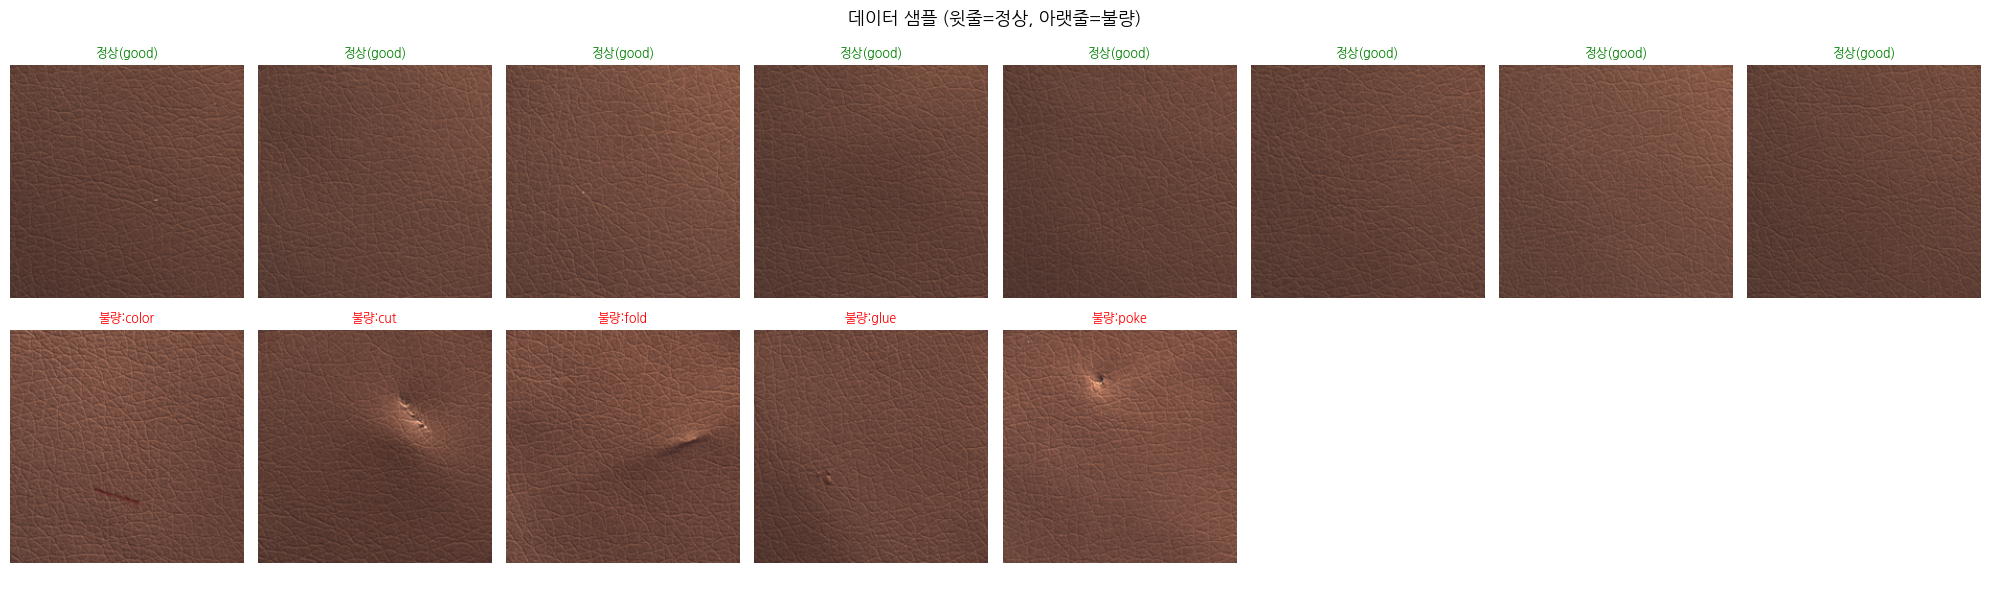

In [10]:
train_good_dir = os.path.join(TRAIN_DIR, "good")
good_files = sorted([f for f in os.listdir(train_good_dir) if f.endswith(".png")])

defect_folders = sorted([f for f in os.listdir(TEST_DIR)
                          if f != "good" and os.path.isdir(os.path.join(TEST_DIR, f))])
defect_samples = []
for folder in defect_folders:
    fp    = os.path.join(TEST_DIR, folder)
    files = [f for f in os.listdir(fp) if f.endswith(".png")]
    if files:
        img = Image.open(os.path.join(fp, random.choice(files))).resize(IMG_SIZE)
        defect_samples.append((img, folder))

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("데이터 샘플 (윗줄=정상, 아랫줄=불량)", fontsize=13)

for i in range(8):
    ax = axes[0, i]
    if i < len(good_files):
        img = Image.open(os.path.join(train_good_dir,
                         random.choice(good_files))).resize(IMG_SIZE)
        ax.imshow(img)
        ax.set_title("정상(good)", color="green", fontsize=9)
    ax.axis("off")

for i in range(8):
    ax = axes[1, i]
    if i < len(defect_samples):
        img, fname = defect_samples[i]
        ax.imshow(img)
        ax.set_title(f"불량:{fname}", color="red", fontsize=9)
    ax.axis("off")

plt.tight_layout() # 여백 관리
plt.show()

## 4단계. 모델 구성 (VGG16 전이학습)

**전이학습(Transfer Learning)이란?**
ImageNet(140만 장)으로 이미 학습된 VGG16의 특징 추출 능력을 그대로 활용합니다.

```
[VGG16 백본 — 전체 동결]    [새로 학습하는 분류 헤드]
이미지 → 특징 추출 (7×7×512)
       → GlobalAveragePooling2D → (512,)
       → Dense(64, relu)
       → Dropout(0.3)
       → Dense(1, sigmoid) → 불량 확률 0~1
```

In [11]:
# ┌─ 채울 곳 ────────────────────────────
# ① 어떤 사전학습 가중치를 쓸 것인가 (문자열)
# ② ImageNet 분류기를 함께 가져올 것인가?
# ③ 특징 추출부를 동결한다 = 학습하지 않는다
# └──────────────────────────────────

base_model = keras.applications.VGG16(
    weights='imagenet',             # ① ImageNet 사전학습 가중치
    include_top=False,         # ② 분류층 제외  특징만 잡기 위함
    input_shape=(*IMG_SIZE, 3) # 색깔이 있어야 하니깐 IMG 크기에 channel은 3 이다
)

# 전체 동결: 데이터가 적으므로 과적합 방지
base_model.trainable = False  # ③ 걍 전체 데이터 VGG16 학습으로 가져옴

print(f"VGG16 레이어 수: {len(base_model.layers)}, 모두 동결")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 레이어 수: 19, 모두 동결


In [12]:
# ┌─ 채울 곳 ──────────────────────────
# ① 특징맵을 채널별 평균 하나로 요약하는 층 이름
# ② 출력 뉴런 수 : 정상/불량 이진 판정이므로 2개
# ③ 결과를 0~1 확률로 만드는 활성화 함수
# └────────────────────────────────

model = keras.Sequential([
    base_model,                                   # VGG16 특징 추출 (7×7×512)
    keras.layers.GlobalAveragePooling2D(),                          # ① (7,7,512) → (512,)
    keras.layers.Dense(64, activation='relu'),    # 완전연결층
    keras.layers.Dropout(0.3),                    # 과적합 방지
    keras.layers.Dense(1, activation='sigmoid',     # ② ③ 불량 확률 0~1 출력
                       name='predictions')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 5단계. 모델 컴파일 & 학습

**class_weight 사용 이유:**
정상 이미지가 불량보다 훨씬 많으므로 불량에 3배 가중치를 주어
모델이 불량을 더 중요하게 학습하도록 합니다.

In [13]:
# ┌─ 채울 곳 ──────────────────────────
# ① 학습률 : 위에서 정의한 상수 LR
# ② 손실 함수 : 이진 분류용 crossentropy (문자열)
# └────────────────────────────────

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),   # ①학습 속도 높여주기 위해서 학습률 설정
    loss='binary_crossentropy',                    # ② 이진 분류 손실함수
    metrics=['accuracy']
)
print("컴파일 완료!")

컴파일 완료!


In [14]:
# ┌─ 채울 곳 ────────────────────────────
# ① 위에서 정의한 클래스 가중치 딕셔너리 이름
#    불량 샘플이 적으므로 손실 계산에서 더 크게 반영한다
# └──────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    class_weight=CLASS_WEIGHT,      # ① 불량 3배 가중치 맞춰주기 위함
    verbose=1
)
print("\n학습 완료!")

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.5220 - loss: 1.5548 - val_accuracy: 0.5676 - val_loss: 0.6682
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 509ms/step - accuracy: 0.5729 - loss: 1.1881 - val_accuracy: 0.6892 - val_loss: 0.6104
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step - accuracy: 0.6339 - loss: 1.1214 - val_accuracy: 0.7568 - val_loss: 0.5401
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 512ms/step - accuracy: 0.6949 - loss: 0.8863 - val_accuracy: 0.7973 - val_loss: 0.4817
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 587ms/step - accuracy: 0.6746 - loss: 0.8952 - val_accuracy: 0.7973 - val_loss: 0.4289
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step - accuracy: 0.7085 - loss: 0.9454 - val_accuracy: 0.8243 - val_loss: 0.4515
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 504ms/step - accuracy: 0.7356 - loss: 0.7401 - val_accuracy: 0.8378 - val_loss: 0.3920
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 460ms/step - accuracy: 0.8034 - loss: 0.6436 - val_accuracy: 

## 6단계. 학습 과정 시각화

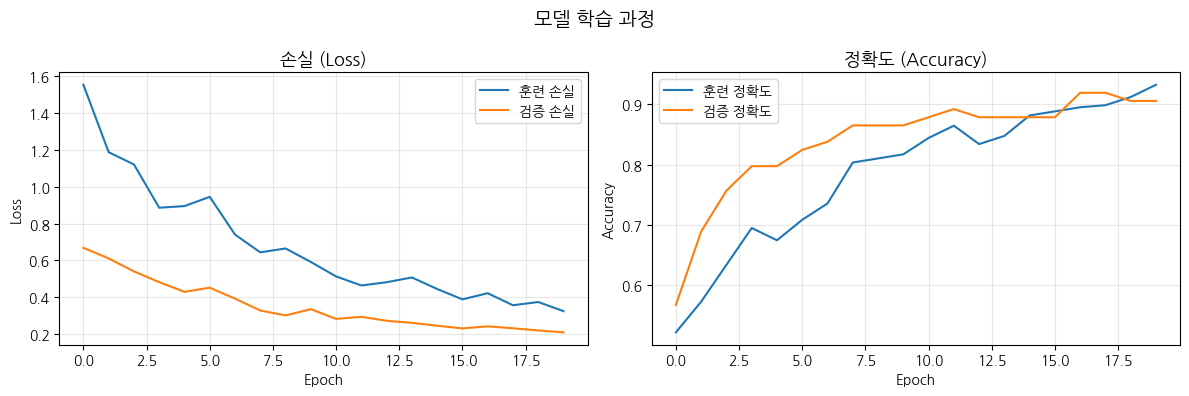

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title('손실 (Loss)', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='훈련 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title('정확도 (Accuracy)', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.suptitle('모델 학습 과정', fontsize=14)
plt.tight_layout(); plt.show()

## 7단계. 모델 평가

```
               예측: 정상   예측: 불량
실제: 정상  [  TN(맞음)   FP(틀림) ]
실제: 불량  [  FN(틀림)   TP(맞음) ]
```
제조 품질 검사에서 **FN(불량을 정상으로 오분류)** 이 가장 위험합니다.

In [16]:
# ┌─ 채울 곳 ───────────────────────────────
# ① 판정 임계값 : 확률이 이 값을 넘으면 불량으로 본다 — 기본 0.5
#    (12차시에서 이 값을 조정하며 정밀도·재현율을 저울질한다)
# └─────────────────────────────────────

preds_prob = model.predict(test_dataset, verbose=1)
preds      = (preds_prob > 0.5).astype(int).flatten()   # ① 이진 분류 니깐 그 임계값을 0.5 또는 다른 부분으로 맞춰줌
y_true     = test_dataset.y_true

acc  = accuracy_score(y_true, preds)
bacc = balanced_accuracy_score(y_true, preds)

print(f"\n정확도 (Accuracy):         {acc:.4f} ({acc:.1%})")
print(f"균형 정확도 (Balanced Acc): {bacc:.4f} ({bacc:.1%})")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 465ms/step

정확도 (Accuracy):         0.9054 (90.5%)
균형 정확도 (Balanced Acc): 0.9019 (90.2%)


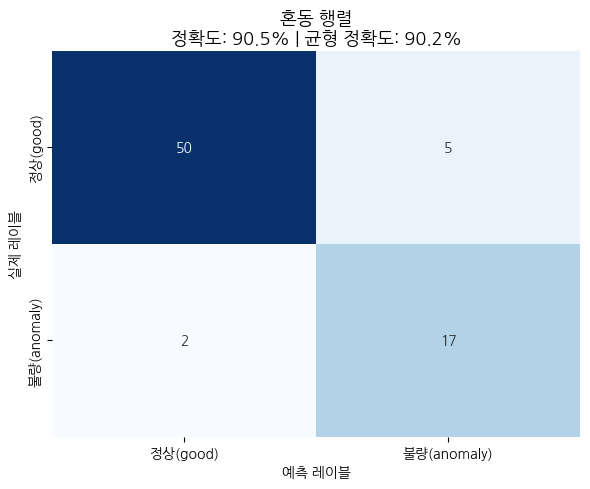

In [17]:
cm       = confusion_matrix(y_true, preds)
label_kr = ["정상(good)", "불량(anomaly)"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=label_kr, yticklabels=label_kr, cmap='Blues')
plt.title(f'혼동 행렬\n정확도: {acc:.1%} | 균형 정확도: {bacc:.1%}', fontsize=13)
plt.ylabel('실제 레이블'); plt.xlabel('예측 레이블')
plt.tight_layout(); plt.show()

## 8단계. 예측 결과 시각화

- 초록색: 정답 / 빨간색: 오답

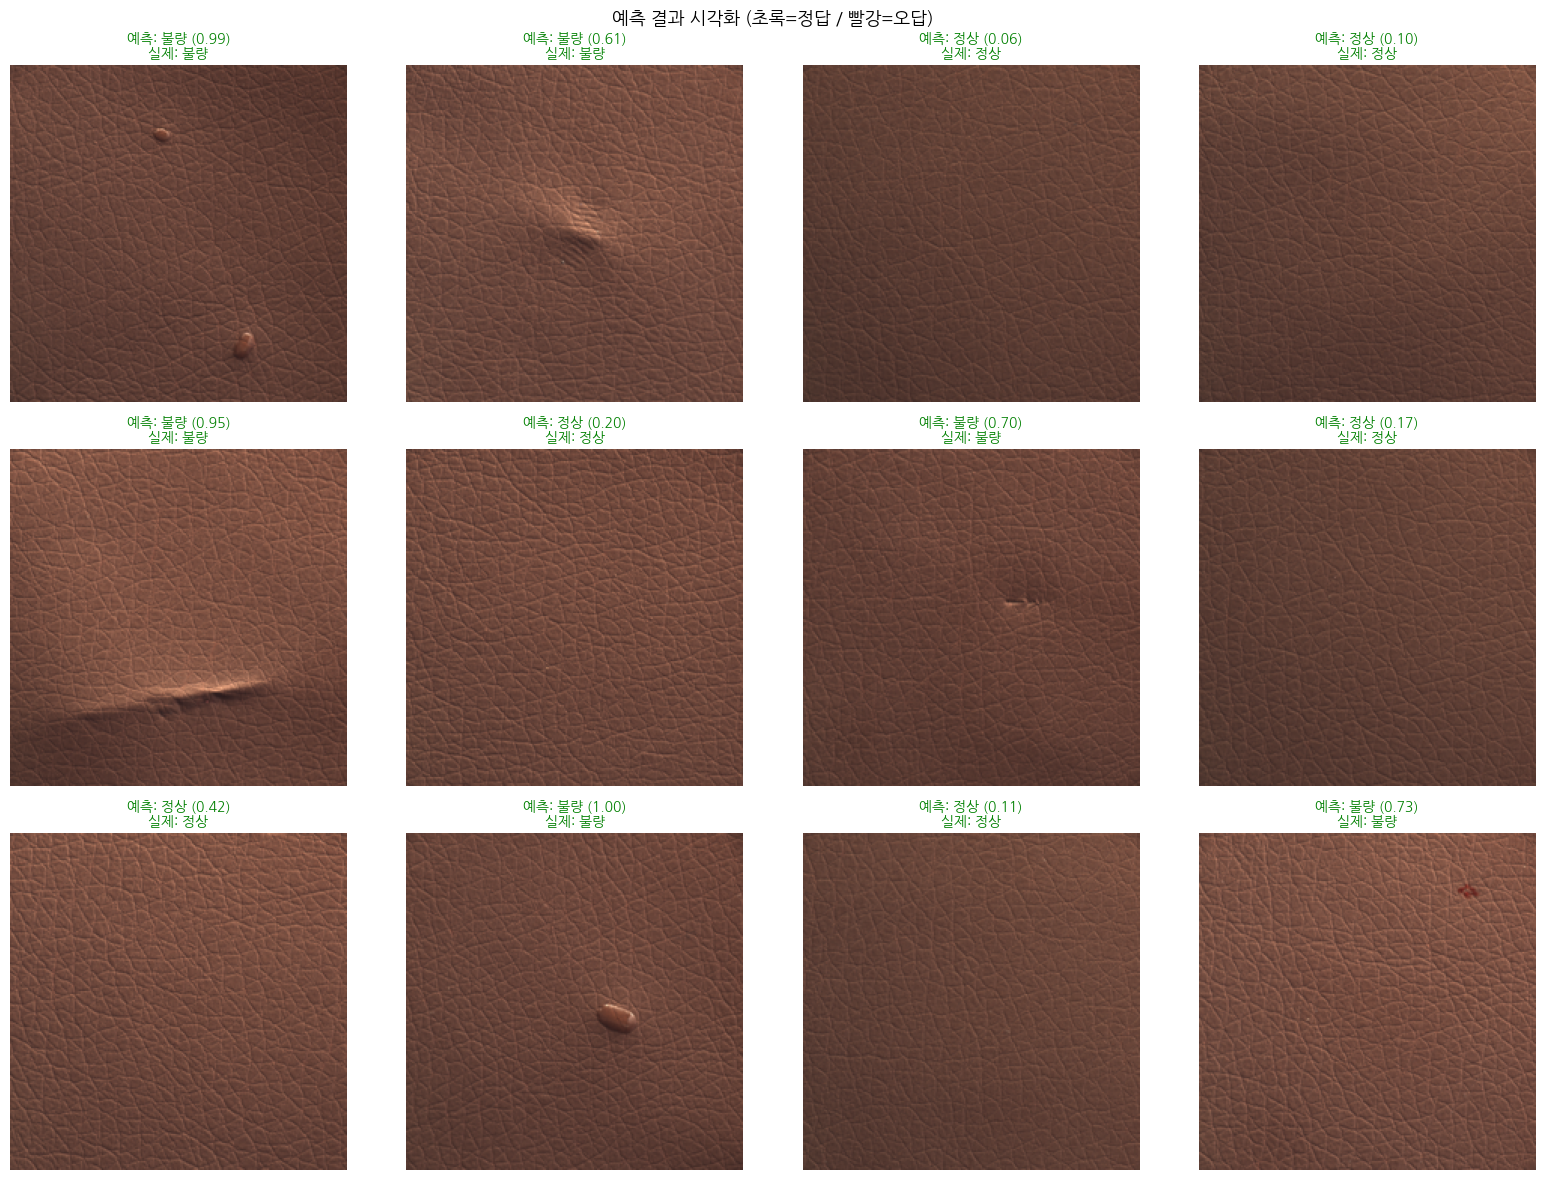

In [18]:
n_display = 12
n_cols    = 4
n_rows    = n_display // n_cols
indices   = np.random.choice(len(test_dataset.image_paths), n_display, replace=False)

plt.figure(figsize=(n_cols * 4, n_rows * 4))

for plot_i, idx in enumerate(indices):
    # 표시용: 원본 이미지 (전처리 전)
    img_pil = Image.open(test_dataset.image_paths[idx]).convert("RGB").resize(IMG_SIZE)

    # 모델 입력용: preprocess_input 적용
    img_arr   = keras.applications.vgg16.preprocess_input(
                    np.array(img_pil, dtype=np.float32).copy())
    img_input = np.expand_dims(img_arr, axis=0)

    prob       = float(model.predict(img_input, verbose=0)[0][0])
    pred_label = "불량" if prob > 0.5 else "정상"
    true_label = "불량" if test_dataset.y_true[idx] == 1 else "정상"
    is_correct = (prob > 0.5) == (test_dataset.y_true[idx] == 1)

    plt.subplot(n_rows, n_cols, plot_i + 1)
    plt.imshow(img_pil)
    plt.axis("off")
    plt.title(
        f"예측: {pred_label} ({prob:.2f})\n실제: {true_label}",
        color="green" if is_correct else "red", fontsize=10
    )

plt.suptitle("예측 결과 시각화 (초록=정답 / 빨강=오답)", fontsize=13)
plt.tight_layout(); plt.show()

## 9단계. 모델 저장

`tf_App.py` 연동을 위해 가중치를 저장합니다.

In [19]:
os.makedirs("weights", exist_ok=True)

# (1) 가중치만 저장 — 같은 구조를 코드로 다시 만들 때 사용
weights_path = "weights/leather_model.weights.h5"
model.save_weights(weights_path)

# (2) 모델 전체 저장 — 12차시(22번 노트북)에서 이 파일을 불러 평가·배포한다 ★
model.save("leather_vgg16.keras")

print(f"가중치 저장 완료: {weights_path}")
print("모델 전체 저장 완료: leather_vgg16.keras   ← 12차시에서 사용")
print("  모델 구조: Sequential (GAP → Dense64 → Dropout → Dense1 sigmoid)")
print("  전처리:   vgg16.preprocess_input  ← 훈련/앱 동일")
print("  출력:     sigmoid 단일값 (0=정상, 1=불량)")

가중치 저장 완료: weights/leather_model.weights.h5
모델 전체 저장 완료: leather_vgg16.keras   ← 12차시에서 사용
  모델 구조: Sequential (GAP → Dense64 → Dropout → Dense1 sigmoid)
  전처리:   vgg16.preprocess_input  ← 훈련/앱 동일
  출력:     sigmoid 단일값 (0=정상, 1=불량)
